In [1]:
import numpy as np

import scarf
from scarf.plotting import CategoricalScale, CellField

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
run = ds.pipeline.open(label="docs_default")

In [2]:
cell_type_by_cluster = {
    "1": "CD14 monocytes",
    "2": "FCGR3A monocytes",
    "3": "B cells",
    "4": "T cells",
    "5": "NK cells",
    "6": "T cells",
    "7": "T cells",
    "8": "B cells",
    "9": "T cells",
    "10": "pDC-like cells",
}
cell_type_order = (
    "CD14 monocytes",
    "FCGR3A monocytes",
    "B cells",
    "T cells",
    "NK cells",
    "pDC-like cells",
)

cluster_values = np.asarray(run.cells.fetch("clusters"))
observed_clusters = {str(value) for value in np.unique(cluster_values)}
assert observed_clusters == set(cell_type_by_cluster)

analysis_cells = np.asarray(run.cells.fetch_all("I"), dtype=bool)
cell_types = np.full(len(analysis_cells), "Not analyzed", dtype=object)
cell_types[analysis_cells] = [
    cell_type_by_cluster[str(value)] for value in cluster_values
]
ds.cells.insert("pbmc_cell_type", cell_types, overwrite=True)
ds.cells.insert("rna_analysis_cells", analysis_cells, overwrite=True)

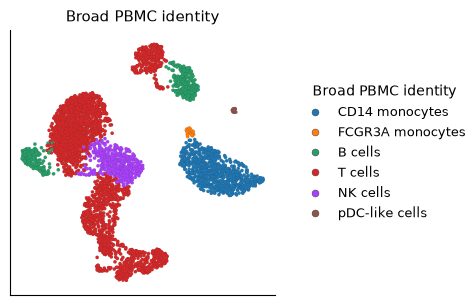

In [3]:
ds.plots.embedding(
    layout=run["umap"],
    color_by=CellField(
        "pbmc_cell_type",
        kind="categorical",
        label="Broad PBMC identity",
    ),
    categorical_scale=CategoricalScale(order=cell_type_order),
    legend_loc="right",
)

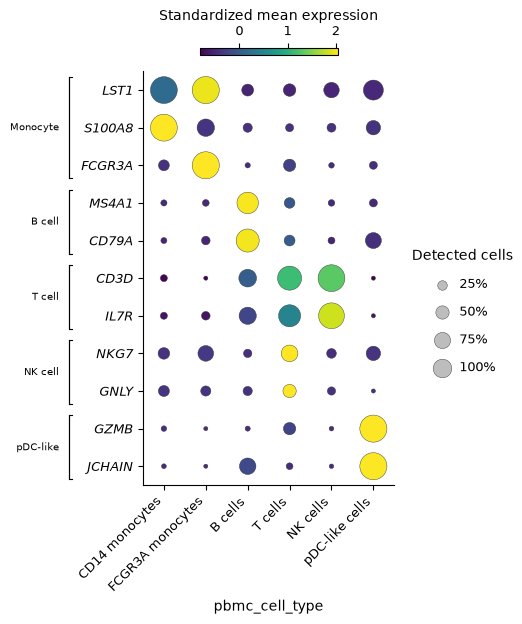

In [4]:
marker_panel = {
    "Monocyte": ["LST1", "S100A8", "FCGR3A"],
    "B cell": ["MS4A1", "CD79A"],
    "T cell": ["CD3D", "IL7R"],
    "NK cell": ["NKG7", "GNLY"],
    "pDC-like": ["GZMB", "JCHAIN"],
}
ds.plots.dotplot(
    features=marker_panel,
    group_by="pbmc_cell_type",
    cell_key="rna_analysis_cells",
    group_order=cell_type_order,
    standardize="feature",
    italicize_features=True,
)